In [13]:
import pandas as pd
import numpy as np
import joblib
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve
)
from category_encoders import TargetEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


In [14]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v2_feas.csv')

In [15]:
num_cols_to_fill = ['transaction_amount', 'time_day', 'time_diff_log']
for col in num_cols_to_fill:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
cat_cols_to_fill = [col for col in df.columns if col not in num_cols_to_fill]
for col in cat_cols_to_fill:
    df[col] = df[col].astype(str)

In [16]:
df = df.drop(columns=['transaction_amount', 'time_day'], axis=1)
v4 = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v4.csv')
df['amt_log'] = v4['amt_log']
df['time_diff_bins'] = pd.cut(df['time_diff_log'], bins=20, include_lowest=True).astype(object)
df['card_type_user_os'] = v4['card_type_user_os']

In [17]:
label = df['is_fraud'].astype(int)
predictors = df.drop(columns=['is_fraud'])
x_train, x_test, y_train, y_test = train_test_split(
    predictors, label, test_size=0.2, random_state=42, stratify=label
)
y_train = y_train.astype(int)
y_test  = y_test.astype(int)
print(y_train.value_counts(normalize=True))

is_fraud
0    0.964982
1    0.035018
Name: proportion, dtype: float64


In [18]:
num_cols    = ['amt_log', 'time_diff_log']
target_cols = ['purchaser_email_domain']
cat_cols    = [col for col in x_train.columns if col not in num_cols + target_cols]

In [19]:
# # Logistic Regression needs scaling on numeric cols
# num_pipeline = Pipeline([
#     ('scaler', StandardScaler())
# ])
# cat_pipeline = Pipeline([
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])
# target_pipeline = Pipeline([
#     ('target', TargetEncoder(smoothing=10, handle_unknown='value'))
# ])
# preprocessor = ColumnTransformer([
#     ('num',    num_pipeline,    num_cols),
#     ('target', target_pipeline, target_cols),
#     ('cat',    cat_pipeline,    cat_cols)
# ])

# neg = int((y_train == 0).sum())
# pos = int((y_train == 1).sum())
# print(f"neg={neg:,}  pos={pos:,}  ratio={neg/pos:.1f}")

# # class_weight='balanced' is logistic regression's version of scale_pos_weight
# model = LogisticRegression(
#     C             = 0.1,           # regularisation (lower = stronger penalty)
#     class_weight  = 'balanced',    # handles fraud imbalance
#     solver        = 'saga',        # best solver for large datasets
#     max_iter      = 1000,
#     random_state  = 42,
#     n_jobs        = -1
# )

# final_pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', model)
# ])
# print("Pipeline ready ✓")

In [20]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cv_predict = cross_val_predict(final_pipe, x_train, y_train, cv=cv, n_jobs=-1)
# joblib.dump(cv_predict, 'cv_predict_lr.pkl')
# print("cv_predict saved ✓", cv_predict.shape)

# cv_proba = cross_val_predict(final_pipe, x_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
# joblib.dump(cv_proba, 'cv_proba_lr.pkl')
# print("cv_proba saved ✓", cv_proba.shape)

In [21]:
# final_pipe.fit(x_train, y_train)
# joblib.dump(final_pipe, 'model_lr.pkl')
# print("Model saved ✓")

In [22]:
cv_predict = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/cv_predict_v4_lr.pkl')
cv_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/cv_proba_v4_lr.pkl')
model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/model_v4_lr.pkl')

In [23]:
print(f"Precision : {precision_score(y_train, cv_predict) * 100:.2f}%")
print(f"Recall    : {recall_score(y_train, cv_predict) * 100:.2f}%")
print()
print(classification_report(y_train, cv_predict))

Precision : 8.74%
Recall    : 62.66%

              precision    recall  f1-score   support

           0       0.98      0.76      0.86    454631
           1       0.09      0.63      0.15     16498

    accuracy                           0.76    471129
   macro avg       0.53      0.69      0.51    471129
weighted avg       0.95      0.76      0.83    471129



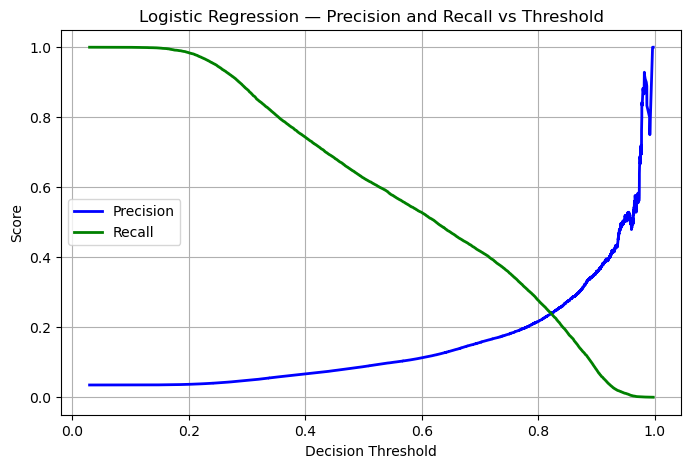

In [24]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_train, cv_proba)
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression — Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()